In [109]:
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags, Mol, molzipFragments
from rdkit.Chem.BRICS import FindBRICSBonds, BreakBRICSBonds

from itertools import combinations, product, permutations
#, molzip, CombineMols, molzipFragments

In [2]:
def isotope_info_to_atom_map_num(mol):
    for at in mol.GetAtoms():
        if at.GetSymbol() == '*':
            info = at.GetIsotope()
            at.SetIsotope(0)
            at.SetAtomMapNum(info)
    return mol

In [3]:
def remove_atom_map_num(mol):
    mn = Mol(mol)
    for at in mn.GetAtoms():
        at.SetAtomMapNum(0)
    return mn

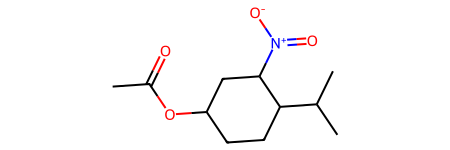

In [4]:
smiles = 'C1C(OC(=O)C)CC([N+](=O)[O-])C(C(C)C)C1'
mol = MolFromSmiles(smiles)
mol

In [5]:
frags = FragmentOnBRICSBonds(mol=mol,
                             )
frags = GetMolFrags(frags,
                    asMols=True)
# frags
frags_smiles = [MolToSmiles(sm) for sm in frags]
frags_smiles

['[15*]C1CCC([15*])C([N+](=O)[O-])C1', '[3*]O[3*]', '[1*]C(C)=O', '[8*]C(C)C']

In [6]:
# generate random contributions
shap_dict = {f: i-1 for i, f in enumerate(frags_smiles)}
shap_dict

{'[15*]C1CCC([15*])C([N+](=O)[O-])C1': -1,
 '[3*]O[3*]': 0,
 '[1*]C(C)=O': 1,
 '[8*]C(C)C': 2}

In [7]:
# random replacement groups here with different number of substitution sites
replacement_smiles = ['*OCC*', '*CCCC', '*CCCCCC', '*CCC*']
replacement_avg_contrib = [-0.5, 0.5, 1.5, 2.5]

In [167]:
n_replacement = [1]
frags_to_replace = (0,)

In [174]:
## now the fun begins

# get list of frags now
mol = MolFromSmiles(smiles)
# start by getting the bonds that are about to be cut
brics_bonds = list(FindBRICSBonds(mol))
# modify in such a way, that the two atoms belonging to the same broken bond have the same isotope information
brics_bonds_mod = [(t[0], (f'{i+1}', f'{i+1}')) for i, t in enumerate(brics_bonds)]
# now we can break the BRICS bonds
brics_broken = BreakBRICSBonds(mol=mol,
                               bonds=brics_bonds_mod,
                               )
# now turn all of the isotope information into AtomMapNum information
brics_broken = isotope_info_to_atom_map_num(brics_broken)
brics_broken_n = remove_atom_map_num(brics_broken)

# these fragments contain the correctly labeled fragments
fragments = GetMolFrags(mol=brics_broken,
                        asMols=True)
fragments_n = GetMolFrags(mol=brics_broken_n,
                          asMols=True)

# get number of attachment points in
n_attachment_points = [sm.count('*') for sm in replacement_smiles]

new_molecules = []

for n in n_replacement:
    print(f'Trying to replace {n} fragments now')
    for replace in combinations(frags_to_replace, n):
        print(f'\tI will replace the following fragments: {replace}')

        # assemble the lists out of which to choose now
        ns_attach = [frags_smiles[i].count('*') for i in replace]
        possible_replacements = [[i for i, e in enumerate(n_attachment_points) if e == l] for l in ns_attach]
        for repl in product(*possible_replacements):
            print(f'\t\t With the following idxs: {repl}')
            # now the replacements start to happen
            # get the replacement numbers
            connecting_idxs = [[at.GetAtomMapNum() for at in fragments[i].GetAtoms() if at.GetSymbol()=='*'] for i in replace]

            comb_connections = []
            for i in range(len(repl)):
                tmp_list = []
                for perm in permutations(connecting_idxs[i], len(connecting_idxs[i])):
                    tmp_list.append(perm)
                comb_connections.append(tmp_list)
            
            replacement_frag = [MolFromSmiles(replacement_smiles[r]) for r in repl]
            comb_frags = []
            for c in product(*comb_connections):
                print(c)
                for idx, frag in enumerate(replacement_frag):
                    at_idxs = [at.GetIdx() for at in frag.GetAtoms() if at.GetSymbol() == '*']
                    for at_idx, n in zip(at_idxs, c[idx]):
                        frag.GetAtomWithIdx(at_idx).SetAtomMapNum(n)
                # now we can try to assemble the original molecule
                new_frags = [Mol(f) for f in fragments]
                for idx, i in enumerate(replace):
                    new_frags[i] = replacement_frag[idx]
                new_molecules.append(molzipFragments(new_frags))
            
# now filter for unique molecules
new_molecules_smiles = [MolToSmiles(m) for m in new_molecules]
new_molecules_smiles = list(set(new_molecules_smiles))

new_molecules = [MolFromSmiles(s) for s in new_molecules_smiles]
        
        


Trying to replace 1 fragments now
	I will replace the following fragments: (0,)
		 With the following idxs: (0,)
((2, 3),)
((3, 2),)
		 With the following idxs: (3,)
((2, 3),)
((3, 2),)


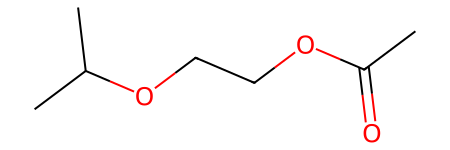

In [178]:
new_molecules[2]